# Results Analysis — XGBoost 12-horizon Forecast

Evaluates model predictions against ground-truth test targets.
**Sections**
Setup & data loading.
Overall metrics (MAE / RMSE per horizon). 
Predicted vs actual scatter\.
Time-series plots for selected odseki.
Residual distribution.
Error heatmap by calendar month.
Feature importance

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

ROOT        = Path("..").resolve()
PRED_PATH   = ROOT / "data" / "predictions" / "predictions.csv"
TARGET_PATH = ROOT / "data" / "processed" / "target.csv"
MODEL_PATH  = ROOT / "models" / "xgb_models.pkl"

TARGET_COLS = [f"h{h}" for h in range(1, 13)]
PRED_COLS   = [f"h{h}_pred" for h in range(1, 13)]
INDEX_COLS  = ["odsek", "leto_mesec"]

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

In [2]:
# Load predictions
preds = pd.read_csv(PRED_PATH)

# Load ground-truth targets (separate from features)
target = pd.read_csv(TARGET_PATH)

# Merge predictions with ground-truth targets on index columns
df = preds.merge(target[["odsek", "leto_mesec"] + TARGET_COLS], on=INDEX_COLS, how="inner")
df["leto_mesec"] = pd.PeriodIndex(df["leto_mesec"], freq="M")

print(f"Rows: {len(df):,}  |  Odseki: {df['odsek'].nunique():,}")
df.head(3)

## 2. Overall metrics per horizon

In [36]:
metrics = []
for h, (tc, pc) in enumerate(zip(TARGET_COLS, PRED_COLS), start=1):
    y_true = df[tc]
    y_pred = df[pc]
    metrics.append({
        "horizon": f"h{h}",
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "bias": (y_pred - y_true).mean(),
    })

metrics_df = pd.DataFrame(metrics).set_index("horizon")

overall_mae  = mean_absolute_error(df[TARGET_COLS].values, df[PRED_COLS].values)
overall_rmse = root_mean_squared_error(df[TARGET_COLS].values, df[PRED_COLS].values)
print(f"Overall MAE : {overall_mae:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}\n")
metrics_df.round(4)

Overall MAE : 6.9975
Overall RMSE: 11.9412



,MAE,RMSE,bias
horizon,,,
h1,7.0609,12.8862,6.8091
h2,6.5306,11.8184,6.2648
h3,5.8932,10.9849,5.6205
h4,5.4623,10.4352,5.1948
h5,4.9047,9.7231,4.6288
h6,4.6392,9.4935,4.3679
h7,4.9353,9.6769,4.6448
h8,6.2631,11.0995,6.0161
h9,7.4065,12.3343,7.1884


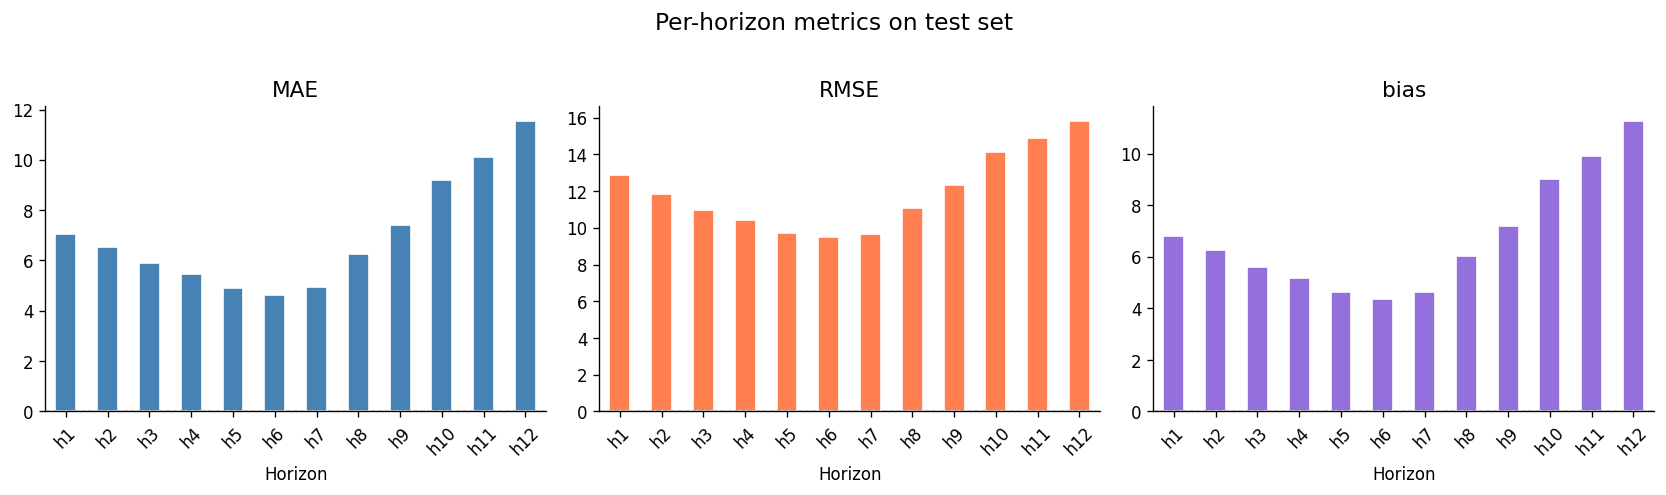

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes, ["MAE", "RMSE", "bias"], ["steelblue", "coral", "mediumpurple"]):
    metrics_df[col].plot(kind="bar", ax=ax, color=color, edgecolor="white")
    ax.set_title(col, fontsize=13)
    ax.set_xlabel("Horizon")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Per-horizon metrics on test set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Predicted vs actual scatter

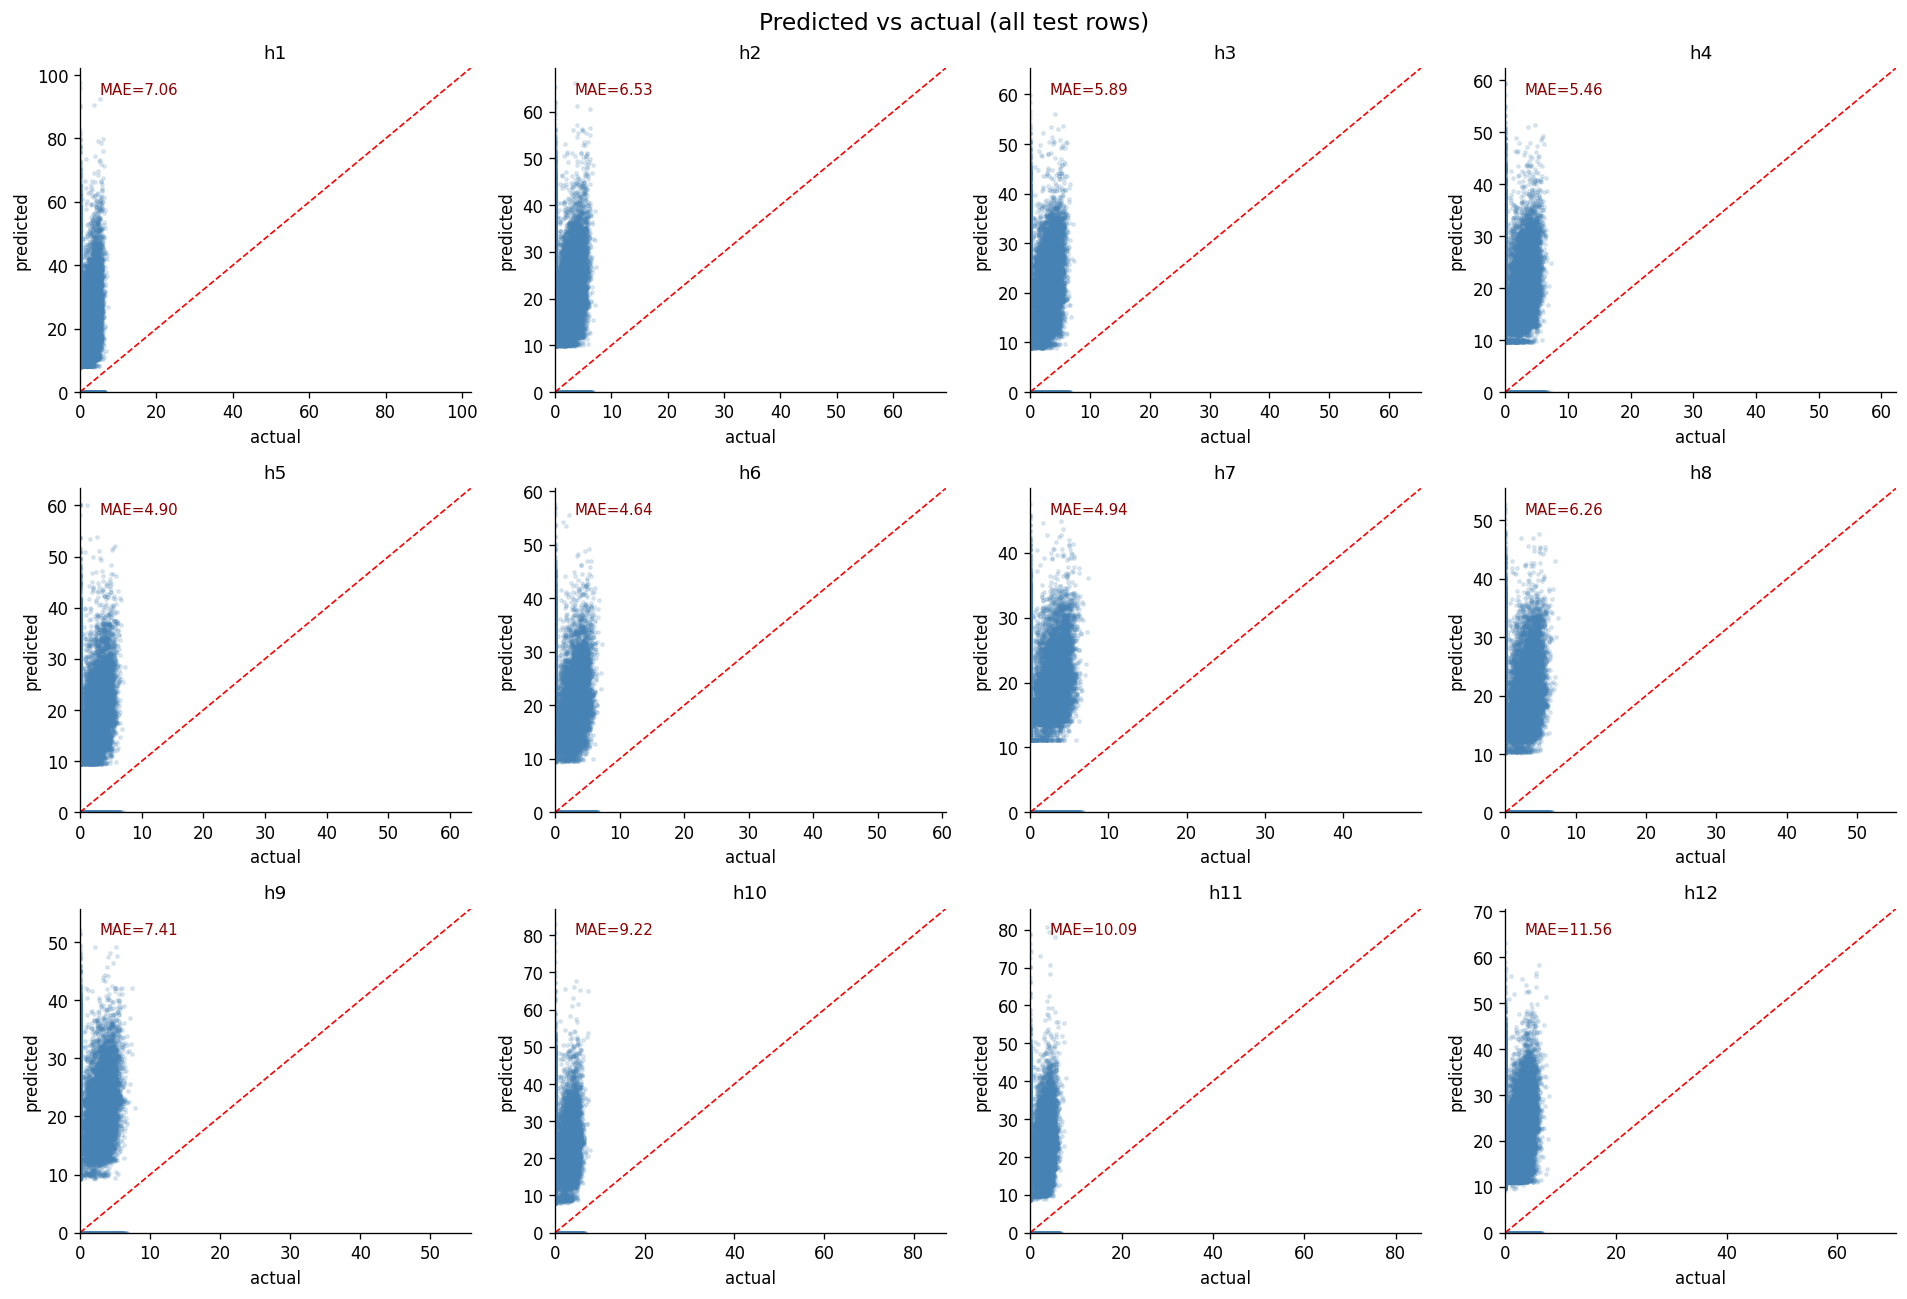

In [38]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))

for ax, tc, pc in zip(axes.flat, TARGET_COLS, PRED_COLS):
    y_true = df[tc].values
    y_pred = df[pc].values
    lim = max(y_true.max(), y_pred.max()) * 1.05

    ax.scatter(y_true, y_pred, alpha=0.15, s=4, color="steelblue", rasterized=True)
    ax.plot([0, lim], [0, lim], "r--", linewidth=1, label="perfect")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_title(tc, fontsize=11)
    ax.set_xlabel("actual")
    ax.set_ylabel("predicted")

    mae = mean_absolute_error(y_true, y_pred)
    ax.text(0.05, 0.92, f"MAE={mae:.2f}", transform=ax.transAxes, fontsize=9, color="darkred")

fig.suptitle("Predicted vs actual (all test rows)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Time-series plots for selected odseki

Shows actual vs predicted h1 (next-month forecast) over the test period for a sample of odseki.

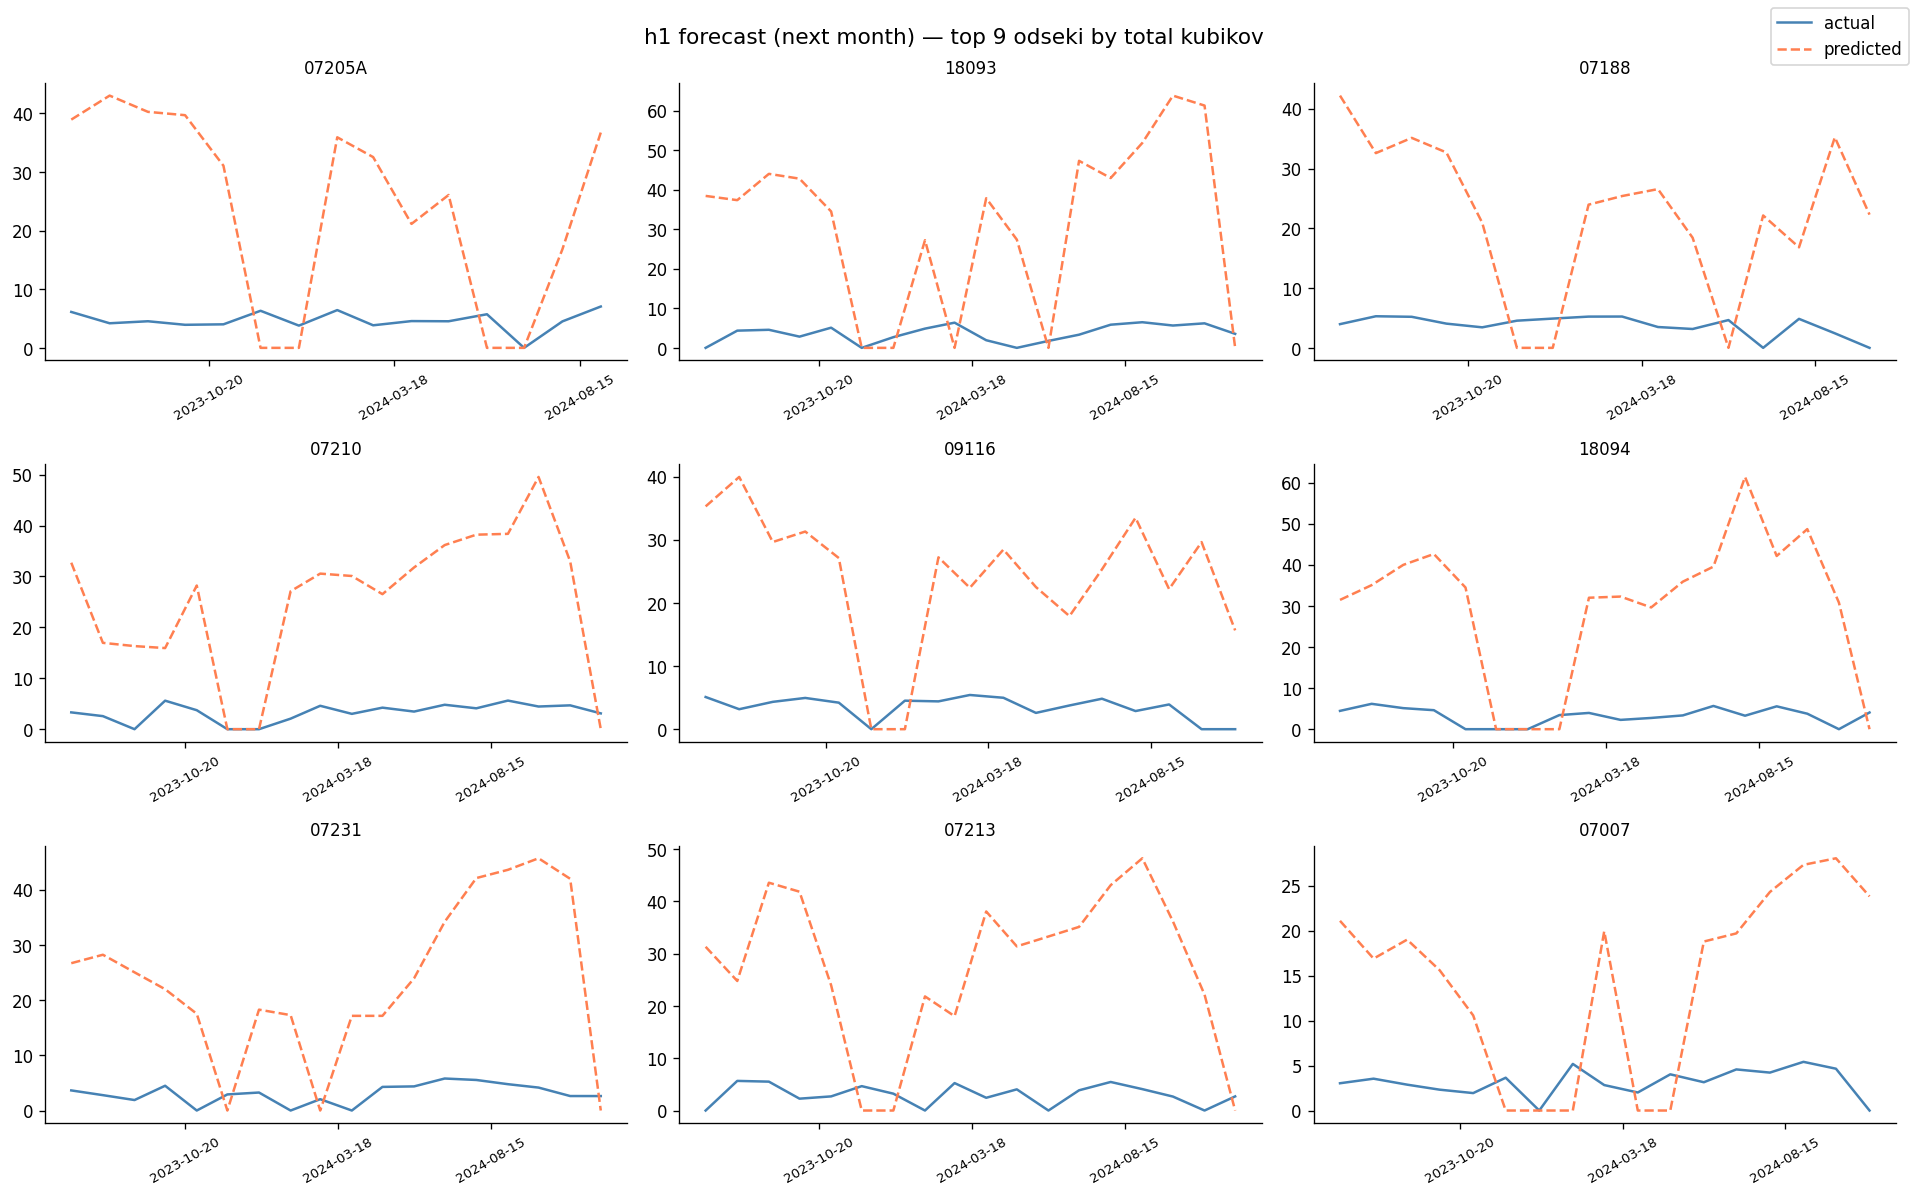

In [39]:
# Pick odseki with the most test rows (most active ones)
top_odseki = (
    df.groupby("odsek")["h1"].sum()
    .nlargest(9)
    .index.tolist()
)

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharey=False)

for ax, odsek in zip(axes.flat, top_odseki):
    sub = df[df["odsek"] == odsek].sort_values("leto_mesec")
    periods = sub["leto_mesec"].dt.to_timestamp()

    ax.plot(periods, sub["h1"],      label="actual",    color="steelblue", linewidth=1.5)
    ax.plot(periods, sub["h1_pred"], label="predicted", color="coral",     linewidth=1.5, linestyle="--")
    ax.set_title(odsek, fontsize=10)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(4))
    ax.tick_params(axis="x", rotation=30, labelsize=8)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=10)
fig.suptitle("h1 forecast (next month) — top 9 odseki by total kubikov", fontsize=13)
plt.tight_layout()
plt.show()

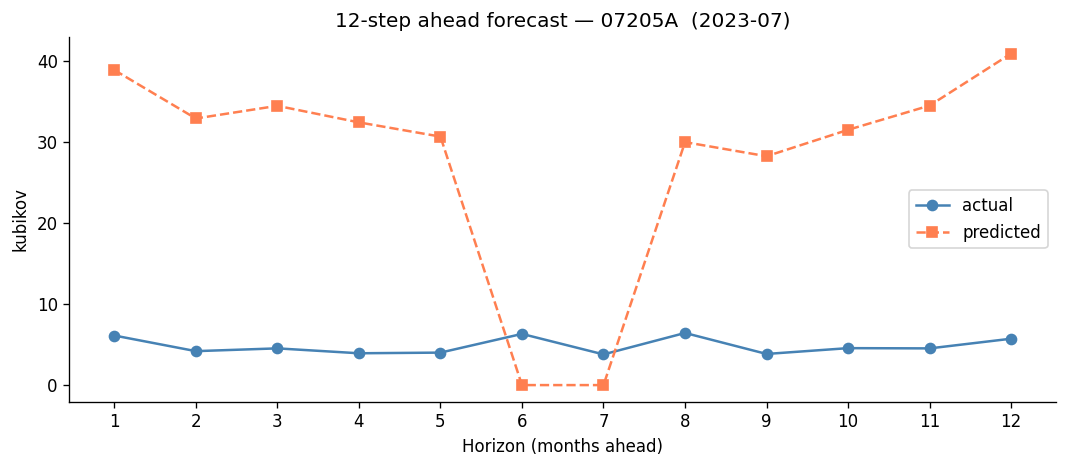

In [40]:
# Full 12-horizon fan plot for a single odsek
odsek_focus = top_odseki[0]
sub = df[df["odsek"] == odsek_focus].sort_values("leto_mesec").head(1)

if not sub.empty:
    row = sub.iloc[0]
    horizons = list(range(1, 13))
    actuals  = [row[f"h{h}"]      for h in horizons]
    forecasts= [row[f"h{h}_pred"] for h in horizons]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(horizons, actuals,   "o-", label="actual",    color="steelblue")
    ax.plot(horizons, forecasts, "s--", label="predicted", color="coral")
    ax.set_xticks(horizons)
    ax.set_xlabel("Horizon (months ahead)")
    ax.set_ylabel("kubikov")
    ax.set_title(f"12-step ahead forecast — {odsek_focus}  ({row['leto_mesec']})")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Residual distribution

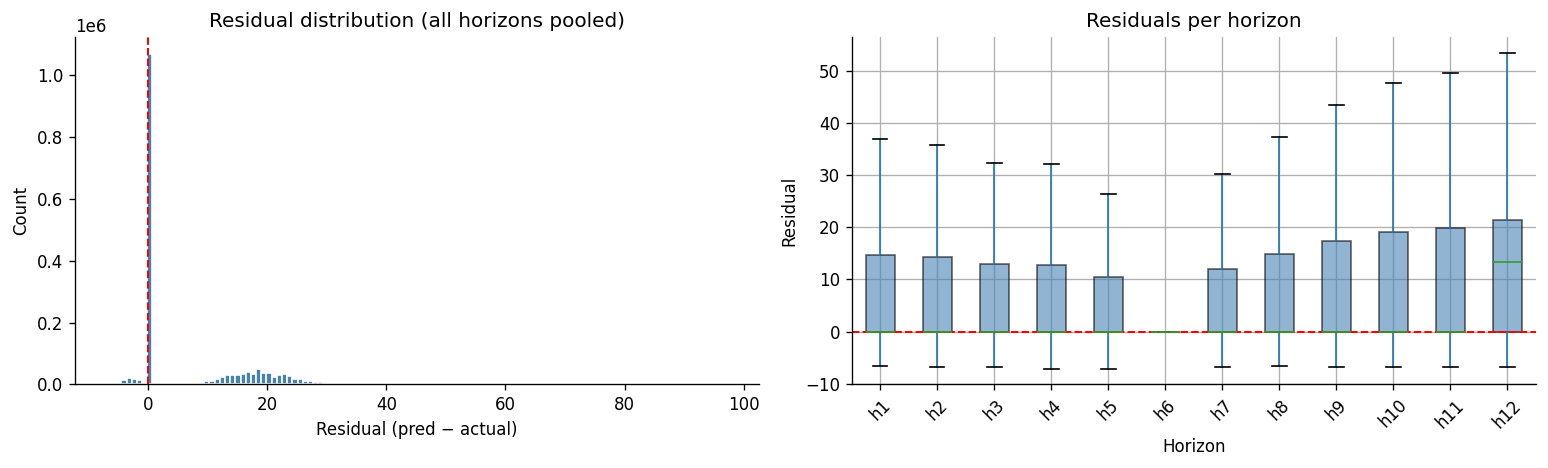

Residual mean : 6.7476
Residual std  : 10.0595
Residual p5/p95: 0.00 / 25.14


In [41]:
# Residuals = predicted - actual, pooled across all horizons
all_residuals = (df[PRED_COLS].values - df[TARGET_COLS].values).ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(all_residuals, bins=120, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Residual (pred − actual)")
axes[0].set_ylabel("Count")
axes[0].set_title("Residual distribution (all horizons pooled)")

# Per-horizon box plots
residuals_per_h = {f"h{h}": df[f"h{h}_pred"].values - df[f"h{h}"].values for h in range(1, 13)}
res_df = pd.DataFrame(residuals_per_h)

res_df.boxplot(ax=axes[1], sym="", notch=False, patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Horizon")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals per horizon")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"Residual mean : {all_residuals.mean():.4f}")
print(f"Residual std  : {all_residuals.std():.4f}")
print(f"Residual p5/p95: {np.percentile(all_residuals, 5):.2f} / {np.percentile(all_residuals, 95):.2f}")

## 6. Error heatmap by calendar month\n\nShows whether prediction error varies by the calendar month of the forecast origin — useful for spotting seasonal bias.

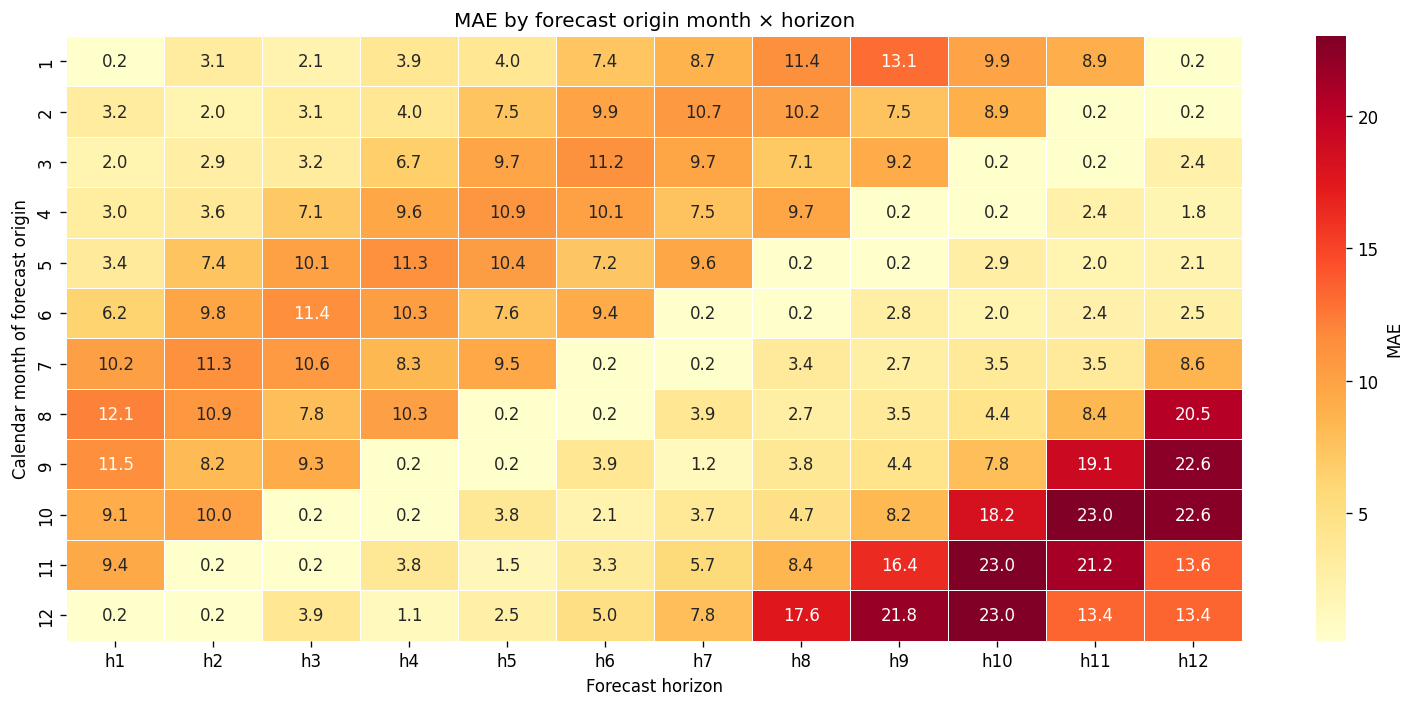

In [42]:
df["origin_month"] = df["leto_mesec"].dt.month

heatmap_data = pd.DataFrame(index=range(1, 13), columns=TARGET_COLS, dtype=float)
for month in range(1, 13):
    sub = df[df["origin_month"] == month]
    for tc, pc in zip(TARGET_COLS, PRED_COLS):
        if len(sub):
            heatmap_data.loc[month, tc] = mean_absolute_error(sub[tc], sub[pc])

heatmap_data.index.name = "origin month"

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    heatmap_data.astype(float),
    ax=ax,
    cmap="YlOrRd",
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    cbar_kws={"label": "MAE"},
)
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("Calendar month of forecast origin")
ax.set_title("MAE by forecast origin month × horizon")
plt.tight_layout()
plt.show()

## 7. Feature importance

Each horizon has **two models**: a classifier (clf) that predicts zero vs non-zero, and a regressor (reg) that predicts the magnitude for non-zero rows.

Sections:
- 7a. Mean gain importance across all 12 horizons — **clf** and **reg** side-by-side
- 7b. Top-15 heatmap per horizon for each model stage
- 7c. Combined importance (average of normalised clf + reg scores)
- 7d. Disagreement — features that matter to one stage but not the other

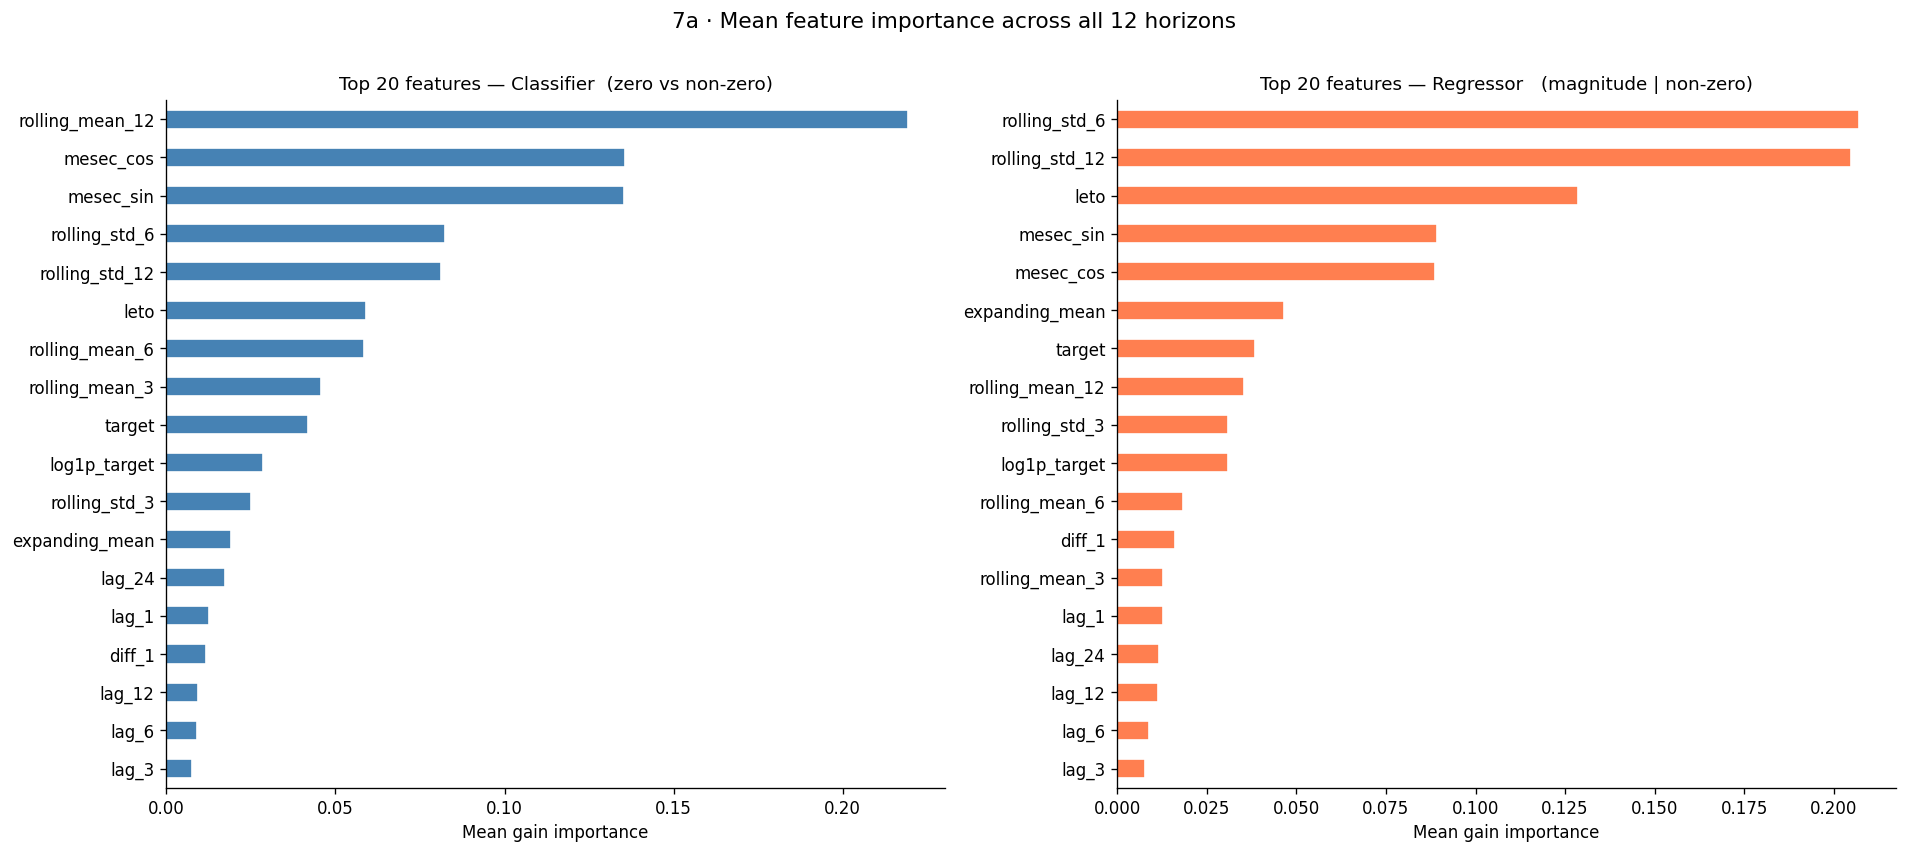

In [43]:
models = joblib.load(MODEL_PATH)

# ── Helper: extract gain importance from one sub-model ───────────────────────
def get_importance(stage_model, feature_cols) -> pd.Series:
    return pd.Series(stage_model.feature_importances_, index=feature_cols)

# ── Build importance DataFrames: rows=features, cols=horizons ────────────────
clf_frames, reg_frames = {}, {}
for col, stage in models.items():
    clf_frames[col] = get_importance(stage["clf"], stage["feature_cols"])
    reg_frames[col] = get_importance(stage["reg"], stage["feature_cols"])

clf_imp = pd.concat(clf_frames, axis=1)   # (n_features × 12)
reg_imp = pd.concat(reg_frames, axis=1)

# Mean across horizons
clf_mean = clf_imp.mean(axis=1).sort_values(ascending=False)
reg_mean = reg_imp.mean(axis=1).sort_values(ascending=False)

# ── 7a. Top-20 bar chart — clf vs reg ────────────────────────────────────────
N = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, mean_imp, title, color in [
    (axes[0], clf_mean, "Classifier  (zero vs non-zero)", "steelblue"),
    (axes[1], reg_mean, "Regressor   (magnitude | non-zero)", "coral"),
]:
    mean_imp.head(N).plot(kind="barh", ax=ax, color=color, edgecolor="white")
    ax.invert_yaxis()
    ax.set_xlabel("Mean gain importance")
    ax.set_title(f"Top {N} features — {title}", fontsize=11)

fig.suptitle("7a · Mean feature importance across all 12 horizons", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

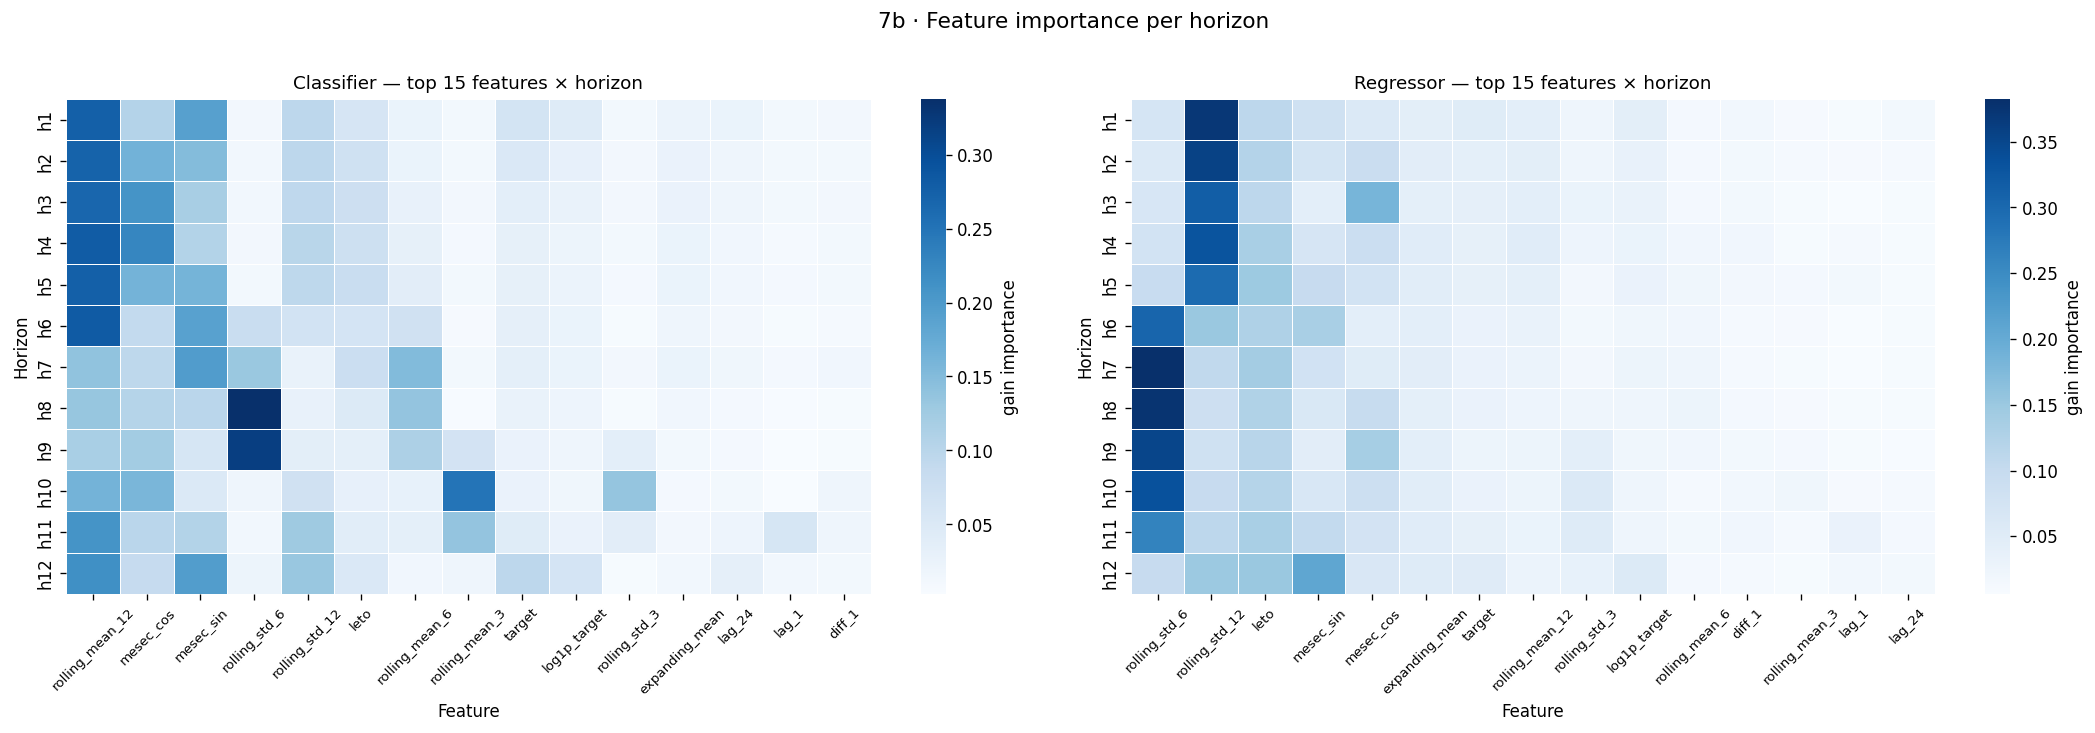

In [44]:
# ── 7b. Heatmap: top-15 features × horizons, one per model stage ─────────────
TOP = 15

clf_top15 = clf_mean.head(TOP).index
reg_top15 = reg_mean.head(TOP).index

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, imp_df, top_feats, title in [
    (axes[0], clf_imp, clf_top15, "Classifier"),
    (axes[1], reg_imp, reg_top15, "Regressor"),
]:
    sns.heatmap(
        imp_df.loc[top_feats].T,
        ax=ax,
        cmap="Blues",
        linewidths=0.3,
        cbar_kws={"label": "gain importance"},
    )
    ax.set_xlabel("Feature")
    ax.set_ylabel("Horizon")
    ax.set_title(f"{title} — top {TOP} features × horizon", fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=8)

fig.suptitle("7b · Feature importance per horizon", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

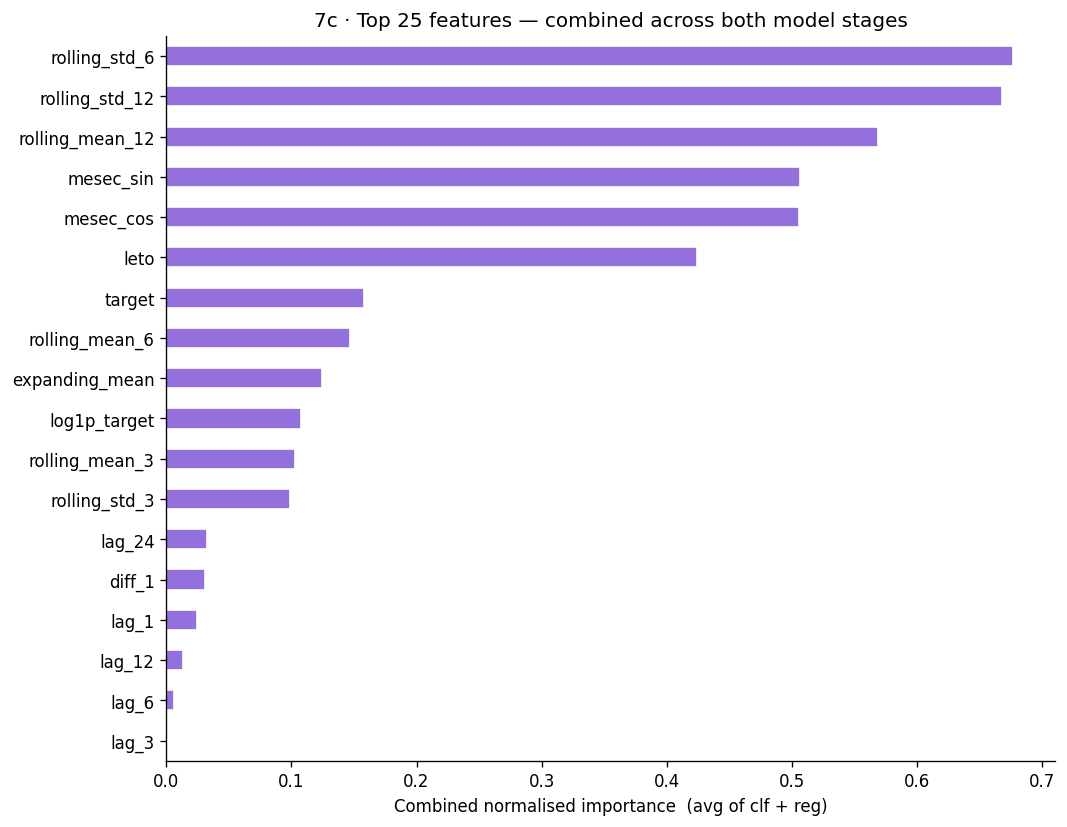

Top 15 combined features:
rolling_std_6      0.6767
rolling_std_12     0.6679
rolling_mean_12    0.5690
mesec_sin          0.5063
mesec_cos          0.5057
leto               0.4246
target             0.1577
rolling_mean_6     0.1465
expanding_mean     0.1244
log1p_target       0.1076
rolling_mean_3     0.1028
rolling_std_3      0.0991
lag_24             0.0326
diff_1             0.0311
lag_1              0.0243


In [45]:
# ── 7c. Combined importance (mean of min-max normalised clf + reg) ────────────
def minmax_norm(s: pd.Series) -> pd.Series:
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0

clf_norm = minmax_norm(clf_mean)
reg_norm = minmax_norm(reg_mean)

# Align on union of features, fill missing with 0
combined = (clf_norm.add(reg_norm, fill_value=0) / 2).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
combined.head(25).plot(kind="barh", ax=ax, color="mediumpurple", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Combined normalised importance  (avg of clf + reg)")
ax.set_title("7c · Top 25 features — combined across both model stages", fontsize=12)
plt.tight_layout()
plt.show()

print("Top 15 combined features:")
print(combined.head(15).round(4).to_string())

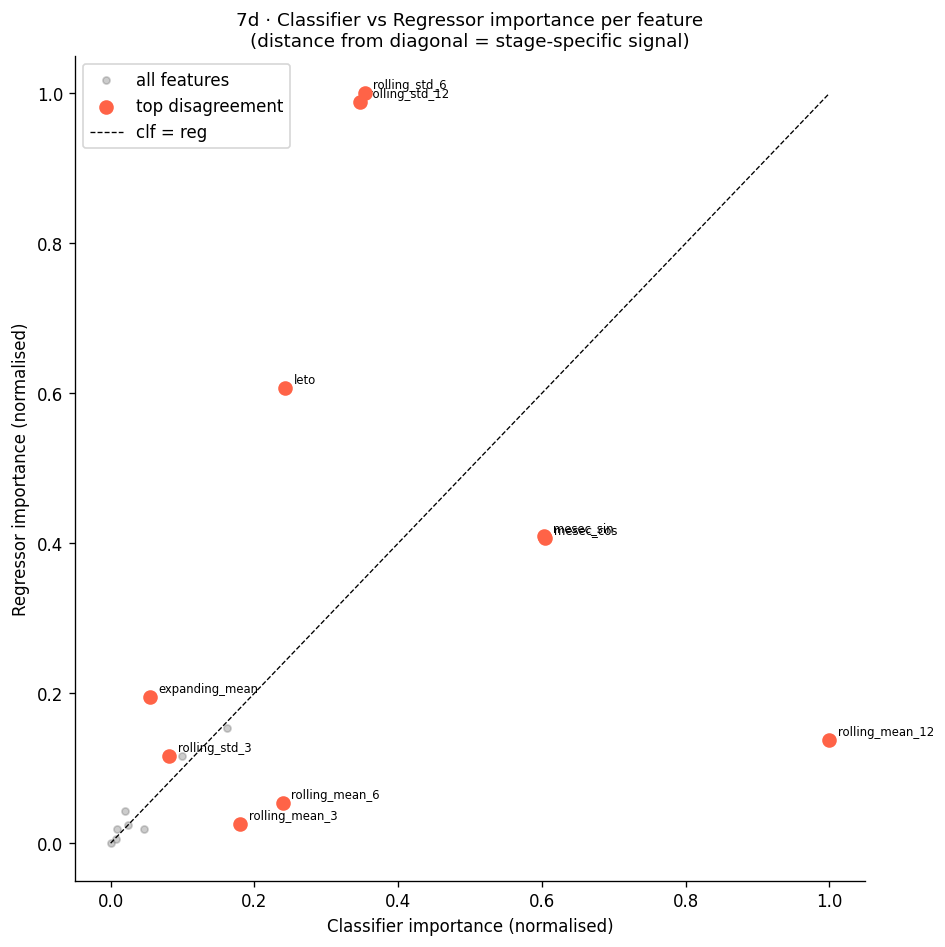


Top 10 features with largest clf vs reg disagreement:
                    clf     reg    diff
rolling_mean_12  1.0000  0.1380  0.8620
rolling_std_6    0.3534  1.0000  0.6466
rolling_std_12   0.3470  0.9889  0.6419
leto             0.2427  0.6064  0.3636
mesec_cos        0.6048  0.4065  0.1983
mesec_sin        0.6033  0.4093  0.1940
rolling_mean_6   0.2398  0.0532  0.1866
rolling_mean_3   0.1806  0.0249  0.1557
expanding_mean   0.0543  0.1945  0.1402
rolling_std_3    0.0817  0.1164  0.0348


In [46]:
# ── 7d. Disagreement — features that matter to one stage but not the other ────
# Scatter: clf normalised score vs reg normalised score for every feature
all_feats = clf_norm.index.union(reg_norm.index)
scatter_df = pd.DataFrame({
    "clf": clf_norm.reindex(all_feats, fill_value=0),
    "reg": reg_norm.reindex(all_feats, fill_value=0),
})
scatter_df["diff"] = (scatter_df["clf"] - scatter_df["reg"]).abs()

# Identify high-disagreement features (top 10 by |clf - reg|)
top_disagree = scatter_df.nlargest(10, "diff")

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    scatter_df["clf"], scatter_df["reg"],
    alpha=0.4, s=18, color="grey", label="all features",
)
ax.scatter(
    top_disagree["clf"], top_disagree["reg"],
    s=60, color="tomato", zorder=5, label="top disagreement",
)
for feat, row in top_disagree.iterrows():
    ax.annotate(feat, (row["clf"], row["reg"]),
                fontsize=7, textcoords="offset points", xytext=(5, 3))

diag = np.linspace(0, 1, 100)
ax.plot(diag, diag, "k--", linewidth=0.8, label="clf = reg")
ax.set_xlabel("Classifier importance (normalised)")
ax.set_ylabel("Regressor importance (normalised)")
ax.set_title("7d · Classifier vs Regressor importance per feature\n"
             "(distance from diagonal = stage-specific signal)", fontsize=11)
ax.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 features with largest clf vs reg disagreement:")
print(top_disagree[["clf", "reg", "diff"]].round(4).to_string())